In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import tensorflow as tf

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "darkgrid")
warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
x = pd.read_csv("../data/cleaned_and_split/x.csv")
x_train = pd.read_csv("../data/cleaned_and_split/x_train.csv")
x_test = pd.read_csv("../data/cleaned_and_split/x_test.csv")
y = pd.read_csv("../data/cleaned_and_split/y.csv")
y_train = pd.read_csv("../data/cleaned_and_split/y_train.csv")
y_test = pd.read_csv("../data/cleaned_and_split/y_test.csv")

In [4]:
x.head()

,Unnamed: 0,x,y,z
0,0,0.04,0.02,1.0
1,1,0.04,0.02,1.0
2,2,0.04,0.02,1.0
3,3,0.04,0.02,1.0
4,4,0.04,0.02,1.0


In [5]:
x_train.head()

,Unnamed: 0,x,y,z
0,9318,0.04,0.03,1.0
1,18896,0.04,0.05,1.0
2,8871,0.04,0.02,1.0
3,18790,0.04,0.04,1.0
4,17362,0.04,0.03,1.0


In [6]:
x_test.head()

,Unnamed: 0,x,y,z
0,10178,-0.14,0.06,0.93
1,8585,0.05,0.02,1.03
2,451,-0.01,0.05,1.12
3,6014,0.04,0.03,1.00
4,15342,0.06,-0.05,1.00


In [7]:
y.head()

,Unnamed: 0,gesture_name
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [8]:
y_train.head()

,Unnamed: 0,gesture_name
0,9318,3
1,18896,6
2,8871,3
3,18790,6
4,17362,6


In [9]:
y_test.head()

,Unnamed: 0,gesture_name
0,10178,3
1,8585,3
2,451,0
3,6014,2
4,15342,5


In [10]:
x.drop(columns = ["Unnamed: 0"], inplace = True)
x_train.drop(columns = ["Unnamed: 0"], inplace = True)
x_test.drop(columns = ["Unnamed: 0"], inplace = True)
y.drop(columns = ["Unnamed: 0"], inplace = True)
y_train.drop(columns = ["Unnamed: 0"], inplace = True)
y_test.drop(columns = ["Unnamed: 0"], inplace = True)

In [11]:
x.head()

,x,y,z
0,0.04,0.02,1.0
1,0.04,0.02,1.0
2,0.04,0.02,1.0
3,0.04,0.02,1.0
4,0.04,0.02,1.0


In [12]:
x_train.head()

,x,y,z
0,0.04,0.03,1.0
1,0.04,0.05,1.0
2,0.04,0.02,1.0
3,0.04,0.04,1.0
4,0.04,0.03,1.0


In [13]:
x_test.head()

,x,y,z
0,-0.14,0.06,0.93
1,0.05,0.02,1.03
2,-0.01,0.05,1.12
3,0.04,0.03,1.00
4,0.06,-0.05,1.00


In [14]:
y.head()

,gesture_name
0,0
1,0
2,0
3,0
4,0


In [15]:
y_train.head()

,gesture_name
0,3
1,6
2,3
3,6
4,6


In [16]:
y_test.head()

,gesture_name
0,3
1,3
2,0
3,2
4,5


In [17]:
x.shape, x_train.shape, x_test.shape, y.shape, y_train.shape, y_test.shape
# ((18008, 3), (14406, 3), (3602, 3), (18008, 1), (14406, 1), (3602, 1))

((18008, 3), (14406, 3), (3602, 3), (18008, 1), (14406, 1), (3602, 1))

In [18]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# create a nn classifier model using functional API
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import LearningRateScheduler

# defining learning rate decay
def scheduler(epochs, lr):
    r_0 = 0.01
    lr = (1/ (1 + r_0 * epochs)) * lr

    return lr

LRdecay = LearningRateScheduler(scheduler)

def create_model_functional():
    # input layer
    inp = Input(shape = (3,))
    # hidden layers
    h1 = Dense(16, activation = "relu", name = "hidden_layer_1")(inp)
    h2 = Dense(32, activation = "relu", name = "hidden_layer_2")(h1)
    h3 = Dense(64, activation = "relu", name = "hidden_layer_3")(h2)
    h4 = Dense(128, activation = "relu", name = "hidden_layer_4")(h3)
    h5 = Dense(64, activation = "relu", name = "hidden_layer_5")(h4)
    h6 = Dense(32, activation = "relu", name = "hidden_layer_6")(h5)
    h7 = Dense(16, activation = "relu", name = "hidden_layer_7")(h6)
    # output layer
    out = Dense(6, activation = "softmax", name = "output_layer")(h7)
    # create model
    model = Model(inputs = inp, outputs = out, name = "gesture_classifier")
    # compile
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
        loss = tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics = ["accuracy"]
    )

    return model

def create_model_sequential():
    model = Sequential(
        [
            Dense(64, activation = "relu", input_shape = (3, ), name = "hidden_layer"),
            Dense(6, activation = "softmax", name = "output_layer")
        ]
    )
    # compile
    model.compile(
        optimizer = tf.keras.optimizers.Adam(beta_1 = 0.9, beta_2 = 0.999),
        loss = tf.keras.losses.SparseCategoricalCrossentropy()
    )

    return model

model = create_model_functional()
# model = create_model_sequential()
model.summary()

2025-05-07 23:00:13.745502: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-05-07 23:00:13.745528: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-05-07 23:00:13.745534: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1746639013.745545 22756214 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1746639013.745566 22756214 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "gesture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_5 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_6 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_7 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,006 (85.96 KB)

 Trainable params: 22,006 (85.96 KB)

 Non-trainable params: 0 (0.00 B)

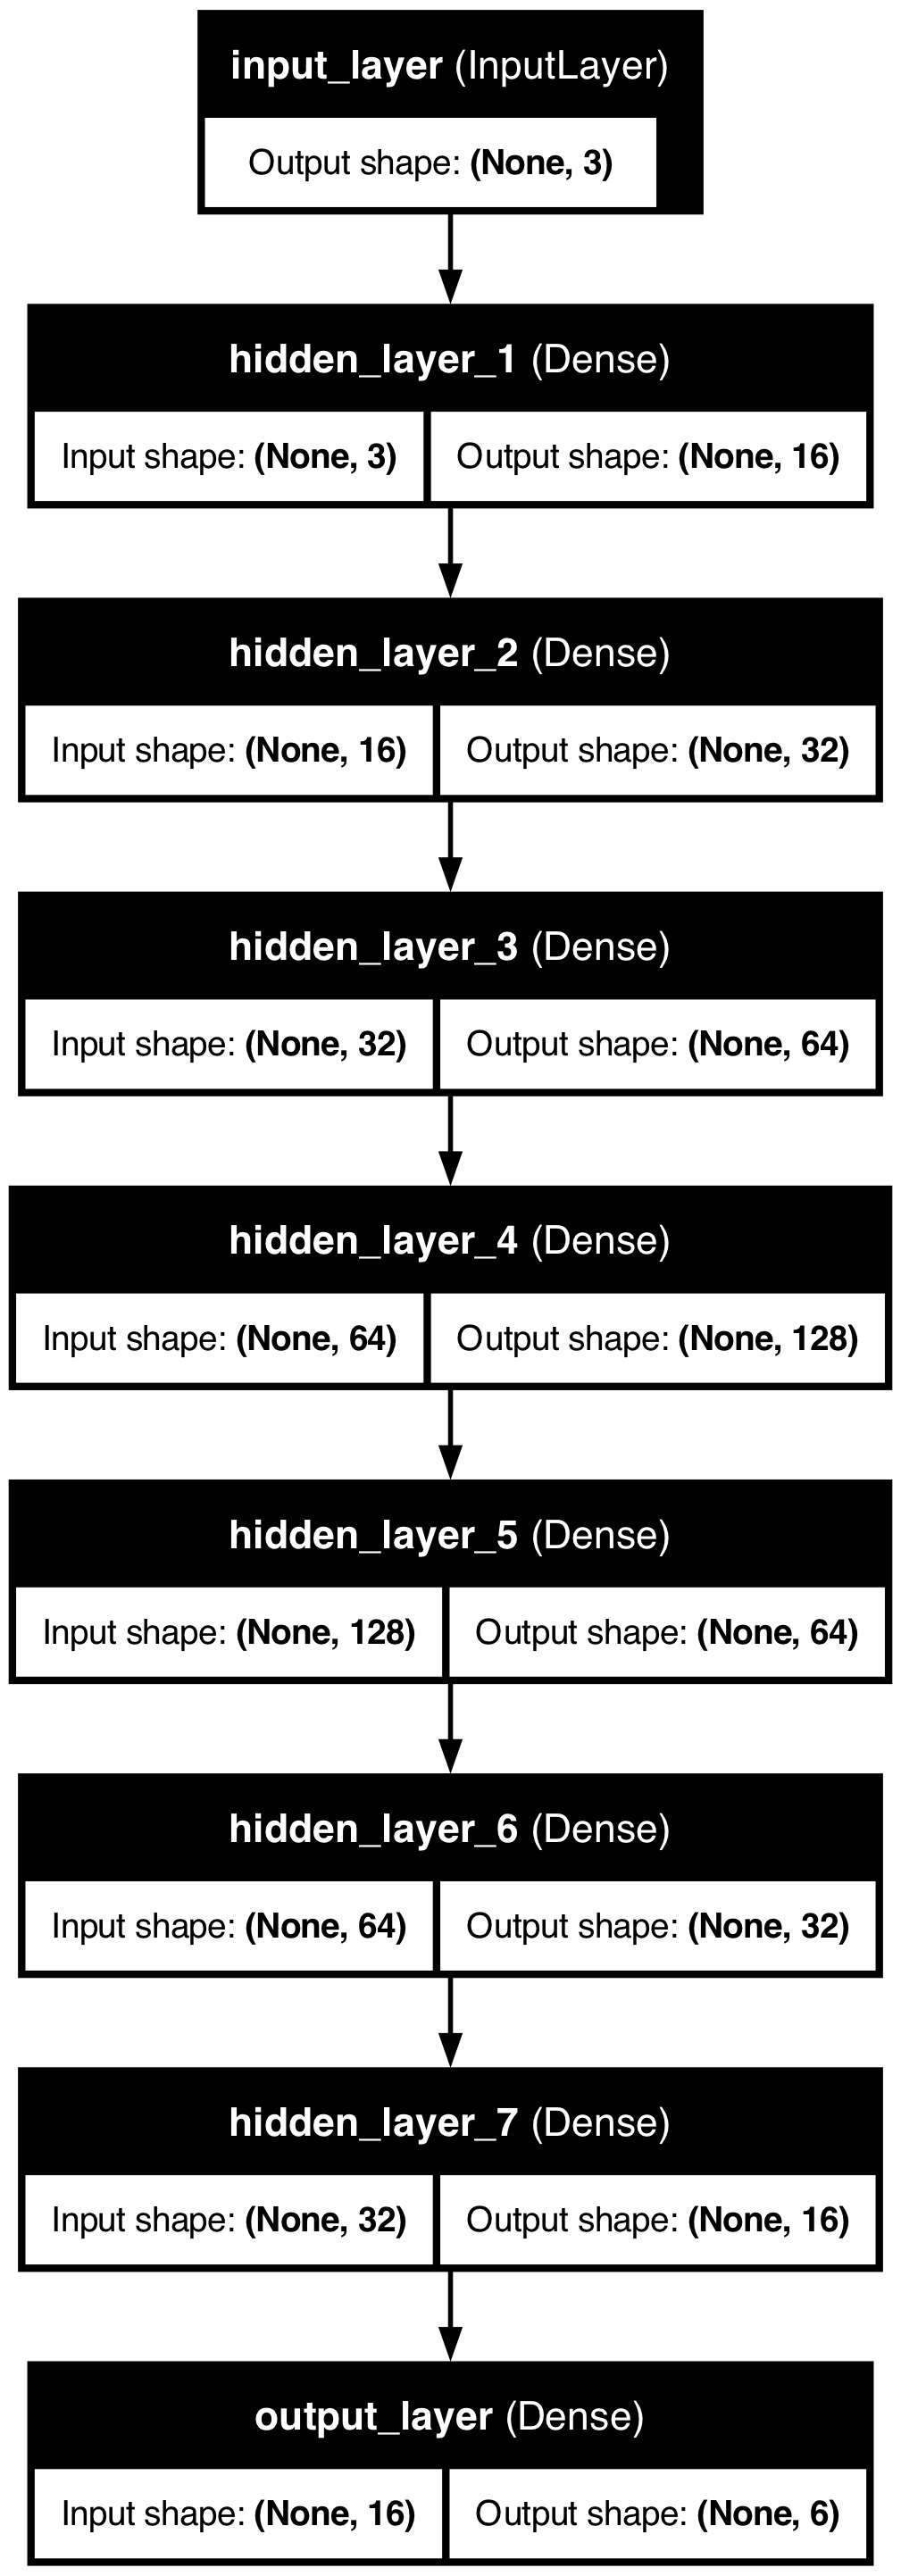

In [20]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file = "model1.png", show_shapes = True, show_layer_names = True)

In [ ]:
# training
epochs = 50
batch_size = 128
history = model.fit(x_train_scaled, y_train, epochs = epochs, batch_size = batch_size, validation_split = 0.1, callbacks = [LRdecay], verbose = 1)

Epoch 1/100


2025-05-07 23:00:14.730839: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: nan - val_loss: nan - learning_rate: 0.1000
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: nan - val_loss: nan - learning_rate: 0.0990
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: nan - val_loss: nan - learning_rate: 0.0971
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: nan - val_loss: nan - learning_rate: 0.0942
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: nan - val_loss: nan - learning_rate: 0.0906
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: nan - val_loss: nan - learning_rate: 0.0863
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: nan - val_loss: nan - learning_rate: 0.0814
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: nan - val_loss: nan - learning_rate: 0.0761
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: nan - val_loss: nan - learning_rate: 0.0705
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: nan - val_loss:

In [ ]:
loss, accuracy = model.evaluate(x_train_scaled, y_train)
loss, accuracy

451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: nan


nan